# N2 — Introdução a LangGraph

* Professor: Júlio Cesar dos Reis <a href="mailto:dosreis@unicamp.br">(dosreis@unicamp.br)</a>
* Monitor: Renan dos Santos Morais <a href="mailto:r299211@dac.unicamp.br">(r299211@dac.unicamp.br)</a> 

Este notebook introduz o LangGraph a partir de exemplos pequenos, executáveis e sem uso de LLMs.

A ideia é construir o entendimento do framework aos poucos, começando pelo modelo de grafos de execução: estado, nós, arestas, atualização de estado, roteamento e ciclos.

Antes de usar LangGraph com modelos de linguagem, vamos entender como ele organiza fluxos de execução de maneira explícita e controlável.

## 0.1 Pré-requisitos

Para acompanhar este notebook, é útil conhecer:

- Python básico;
- funções;
- dicionários;
- tipagem simples com `TypedDict`;

## 0.2 Objetivos da aula

Ao final deste notebook, você deverá saber:

1. Entender por que grafos são úteis para modelar aplicações com múltiplas etapas.
2. Representar um fluxo usando nós, arestas e estado.
3. Criar um primeiro grafo com `StateGraph`.
4. Implementar operações dentro de nós.
5. Encadear uma sequência de nós.
6. Usar roteamento condicional.
7. Usar reducers para acumular informações no estado.
8. Criar um ciclo controlado.

## 0.3 Mapa do notebook

Neste notebook, vamos passar por:

1. Além do fluxo linear.
2. O modelo de grafos em LangGraph.
3. Estado, nós e arestas.
4. Primeiro grafo com `StateGraph`.
5. Sequência de nós.
6. Roteamento condicional.
7. Acúmulo de informações com reducers.
8. Ciclos controlados.

## 0.4 Preparação do ambiente

Para executar este notebook, é necessário ter o `langgraph` instalado.

Em um ambiente novo, execute a célula abaixo descomentando a linha de instalação.


In [14]:
# Descomente se estiver em um ambiente sem LangGraph instalado.
%pip install -U langgraph

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Agora importamos os elementos que serão usados ao longo da aula.

In [15]:
from typing import TypedDict, Literal, Annotated
from operator import add

from langgraph.graph import StateGraph, START, END

Agora importamos os elementos básicos que serão usados ao longo da aula.

- `StateGraph`: construtor do grafo.
- `START`: ponto inicial do grafo.
- `END`: ponto final do grafo.
- `TypedDict`: usado para declarar o formato esperado do estado.
- `Literal`: usado para tipar rotas condicionais.
- `Annotated` e `operator.add`: usados mais adiante para reducers.


Vamos criar uma função auxiliar para exibir os grafos compilados

In [16]:
from langgraph.graph.state import CompiledStateGraph
from IPython.display import Image, display

def display_graph(graph: CompiledStateGraph) -> None:
    display(Image(graph.get_graph().draw_mermaid_png()))

---

# 1. Além do fluxo linear com LLMs.

Uma aplicação simples com LLM pode ser pensada como uma linha reta:

```text
entrada → prompt → modelo → resposta
```

Mas aplicações mais realistas costumam precisar de:

- múltiplas etapas;
- decisões condicionais;
- estado compartilhado;
- memória de execução;
- loops de tentativa e revisão;
- chamadas de ferramentas;
- inspeção do que aconteceu em cada etapa.

O LangGraph permite modelar esse tipo de aplicação como um **grafo de execução**.

Em vez de escrever apenas uma sequência linear, descrevemos:

- quais etapas existem;
- qual estado cada etapa lê;
- qual atualização cada etapa devolve;
- para onde o fluxo segue depois de cada etapa.


## 1.1 A lógica central do LangGraph

A ideia mais importante do LangGraph é:

```text
estado atual → nó → atualização parcial do estado
```

Um nó recebe o estado atual, executa uma tarefa e devolve apenas o que mudou.

Exemplo conceitual:

```text
Estado inicial:
{"nome": "Julio"}

Nó:
gerar_mensagem_boas_vindas

Atualização:
{"mensagem": "Olá, Julio! Você está aprendendo LangGraph."}

Estado final:
{
  "nome": "Julio",
  "mensagem": "Olá, Julio! Você está aprendendo LangGraph."
}
```

Essa lógica aparecerá em todos os exemplos.


---

# 2. Primeiro grafo: nó simples

Vamos começar com o menor exemplo útil: um grafo com apenas um nó.

Fluxo:

```text
START → boas_vindas → END
```

Esse exemplo serve para entender a anatomia básica de um grafo em LangGraph.


In [17]:
class EstadoBoasVindas(TypedDict):
    nome: str
    mensagem: str


def gerar_mensagem_boas_vindas(state: EstadoBoasVindas) -> dict:
    """Recebe o estado e devolve apenas a mensagem gerada."""
    mensagem = f"Olá, {state['nome']}! Você está aprendendo LangGraph."
    return {"mensagem": mensagem}


builder = StateGraph(EstadoBoasVindas)

builder.add_node("boas_vindas", gerar_mensagem_boas_vindas)

builder.add_edge(START, "boas_vindas")
builder.add_edge("boas_vindas", END)

graph = builder.compile()

resultado = graph.invoke({"nome": "Julio"})

print(resultado)

{'nome': 'Julio', 'mensagem': 'Olá, Julio! Você está aprendendo LangGraph.'}


## 2.1 O que aconteceu?

1. Declaramos o estado com `TypedDict`.
2. Criamos uma função que representa um nó.
3. Criamos um `StateGraph`.
4. Registramos o nó com `add_node`.
5. Conectamos `START` ao nó.
6. Conectamos o nó ao `END`.
7. Compilamos o grafo.
8. Executamos com `invoke`.

Observe que o input tinha apenas `nome`, mas o output passou a ter também `mensagem`.

Isso acontece porque o nó devolveu uma **atualização parcial do estado**.


Utilizamos `TypedDict` para declarar o formato esperado do estado.

Essa é uma forma simples e leve de explicitar quais campos compõem o estado do grafo e quais tipos esperamos em cada campo.

Existem outras formas de declarar estado em LangGraph. Uma alternativa comum é usar modelos do Pydantic, por meio de `BaseModel`, que permitem validação mais estruturada, valores padrão, descrições de campos e regras adicionais.

Em aulas posteriores, vamos usar `BaseModel` quando fizer sentido trabalhar com esquemas mais ricos e saídas estruturadas, podendendo fazer uso da `with_structured_output`. Por enquanto, nesta aula, vamos manter o estado com `TypedDict`, porque ele é suficiente para entender os fundamentos de estado, nós, arestas e atualizações parciais.

## 2.2 Visualizando o desenho do grafo

O método a seguir gera uma visualização do grafo a partir da sua representação Mermaid.

Neste exemplo, usamos `draw_mermaid_png()` para renderizar o grafo como uma imagem PNG e exibimos o resultado diretamente no notebook com `display(Image(...))`. 

Aqui, mostramos como esse método funciona, porém, no restante do código utilizaremos a função auxiliar `display_graph()` criada na preparação do ambiente.

Isso facilita a compreensão da estrutura do grafo, mostrando visualmente os nós e as conexões entre eles.

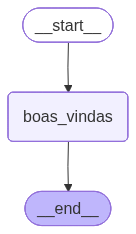

In [18]:
display(Image(graph.get_graph().draw_mermaid_png()))

---

# 3. Operação dentro de um nó

Agora vamos fazer uma operação simples: calcular a média de um aluno.

Fluxo:

```text
START → calcular_media_aluno → END
```

Este exemplo mostra que um nó não precisa ser uma chamada a um LLM.  
Um nó pode ser apenas lógica Python.


{'nome': 'Julio', 'notas': [9, 8, 10], 'media': 9.0, 'mensagem': 'Olá, Julio! Sua média foi: 9.00.'}


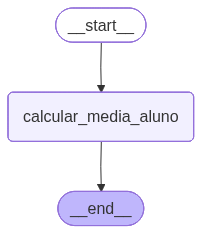

In [19]:
class EstadoDesempenhoAluno(TypedDict):
    nome: str
    notas: list[float]
    media: float
    mensagem: str


def calcular_media_aluno(state: EstadoDesempenhoAluno) -> dict:
    """Calcula a média e devolve apenas os campos novos."""
    notas = state["notas"]
    media = sum(notas) / len(notas)

    return {
        "media": media,
        "mensagem": f"Olá, {state['nome']}! Sua média foi: {media:.2f}."
    }


builder = StateGraph(EstadoDesempenhoAluno)

builder.add_node("calcular_media_aluno", calcular_media_aluno)

builder.add_edge(START, "calcular_media_aluno")
builder.add_edge("calcular_media_aluno", END)

graph = builder.compile()

resultado = graph.invoke({
    "nome": "Julio",
    "notas": [9, 8, 10]
})

print(resultado)
display_graph(graph)

## 3.1 Boa prática: devolver atualização parcial

No exemplo anterior, poderíamos modificar o `state` diretamente e retornar o estado inteiro.

Porém, para fins didáticos apresentamos dessa maneira:

```python
return {
    "campo_novo": valor,
    "outro_campo": outro_valor
}
```

Vantagens:

- deixa claro o que o nó altera;
- reduz efeitos colaterais;
- facilita debug;
- prepara o aluno para entender reducers;
- torna o contrato entre nós mais explícito.

Pense no nó como uma função que diz:

> “Recebi este estado e estou propondo estas atualizações.”


---

# 4. Sequência de nós

Agora vamos transformar uma operação única em uma sequência.

Objetivo:

1. Calcular a média da primeira etapa.
2. Calcular a média da segunda etapa.
3. Calcular a média geral.
4. Gerar um relatório final.

Fluxo:

```text
START
  ↓
calcular_medias_por_etapa
  ↓
calcular_media_final
  ↓
gerar_relatorio_de_notas
  ↓
END
```

Aqui fica mais claro que cada nó pode ter uma responsabilidade pequena e bem definida.


{'nome': 'Julio', 'notas1': [7, 8, 9], 'notas2': [10, 8, 7.5], 'media1': 8.0, 'media2': 8.5, 'media_geral': 8.25, 'mensagem': 'Olá, Julio! Suas médias foram 8.00 e 8.50. Sua média geral foi 8.25.'}


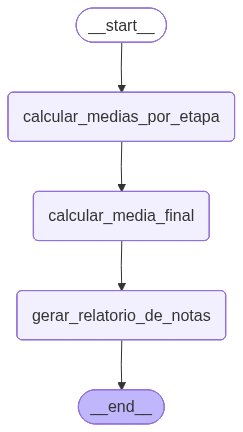

In [20]:
class EstadoNotasAluno(TypedDict):
    nome: str
    notas1: list[float]
    notas2: list[float]

    media1: float
    media2: float
    media_geral: float

    mensagem: str


def calcular_medias_por_etapa(state: EstadoNotasAluno) -> dict:
    media1 = sum(state["notas1"]) / len(state["notas1"])
    media2 = sum(state["notas2"]) / len(state["notas2"])

    return {
        "media1": media1,
        "media2": media2
    }


def calcular_media_final(state: EstadoNotasAluno) -> dict:
    media_geral = (state["media1"] + state["media2"]) / 2

    return {
        "media_geral": media_geral
    }


def gerar_relatorio_de_notas(state: EstadoNotasAluno) -> dict:
    mensagem = (
        f"Olá, {state['nome']}! "
        f"Suas médias foram {state['media1']:.2f} e {state['media2']:.2f}. "
        f"Sua média geral foi {state['media_geral']:.2f}."
    )

    return {
        "mensagem": mensagem
    }


builder = StateGraph(EstadoNotasAluno)

builder.add_node("calcular_medias_por_etapa", calcular_medias_por_etapa)
builder.add_node("calcular_media_final", calcular_media_final)
builder.add_node("gerar_relatorio_de_notas", gerar_relatorio_de_notas)

builder.add_edge(START, "calcular_medias_por_etapa")
builder.add_edge("calcular_medias_por_etapa", "calcular_media_final")
builder.add_edge("calcular_media_final", "gerar_relatorio_de_notas")
builder.add_edge("gerar_relatorio_de_notas", END)

graph = builder.compile()

resultado = graph.invoke({
    "nome": "Julio",
    "notas1": [7, 8, 9],
    "notas2": [10, 8, 7.5]
})

print(resultado)
display_graph(graph)

## 4.1 Por que dividir em vários nós?

Poderíamos fazer tudo em uma única função.

Mas dividir em nós separados tem vantagens:

- cada função fica mais simples;
- cada etapa pode ser testada isoladamente;
- o grafo fica mais legível;
- fica mais fácil inserir novas etapas no futuro;
- fica mais fácil debugar a execução;
- fica mais natural transformar o fluxo em algo condicional depois.

Essa é uma das principais ideias de design em LangGraph:

> O grafo deve revelar a arquitetura do fluxo.


---

# 5. Roteamento condicional

Até agora, os grafos seguiram sempre uma linha reta.

Agora vamos criar um grafo que escolhe o próximo caminho com base no estado.

Objetivo:

- se `operacao == "media"`, calcular a média;
- se `operacao == "soma"`, calcular a soma;
- se `operacao == "maior_nota"`, encontrar a maior nota;
- caso contrário, retornar uma mensagem de operação inválida.

Fluxo:

```text
START
  ↓
router
  ├── media
  ├── soma
  ├── maior_nota
  └── operacao_invalida
  ↓
END
```


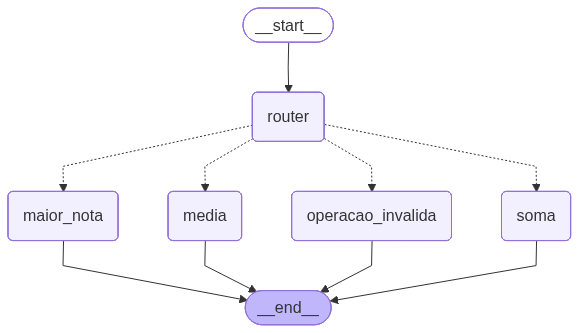

In [22]:
class EstadoOperacaoAluno(TypedDict):
    nome: str
    notas: list[float]
    operacao: str
    mensagem: str


def preparar_roteamento(state: EstadoOperacaoAluno) -> dict:
    """Nó de passagem.

    Ele existe para marcar o ponto do grafo em que a decisão será tomada.
    Não precisa alterar o estado.
    """
    return {}


def router(state: EstadoOperacaoAluno) -> Literal[
    "media",
    "soma",
    "maior_nota",
    "operacao_invalida"
]:
    operacao = state["operacao"]

    if operacao == "media":
        return "media"

    if operacao == "soma":
        return "soma"

    if operacao == "maior_nota":
        return "maior_nota"

    return "operacao_invalida"


def calcular_media(state: EstadoOperacaoAluno) -> dict:
    media = sum(state["notas"]) / len(state["notas"])

    return {
        "mensagem": f"Olá, {state['nome']}! Sua média foi {media:.2f}."
    }


def calcular_soma(state: EstadoOperacaoAluno) -> dict:
    soma = sum(state["notas"])

    return {
        "mensagem": f"Olá, {state['nome']}! A soma das suas notas é {soma:.2f}."
    }


def encontrar_maior_nota(state: EstadoOperacaoAluno) -> dict:
    maior_nota = max(state["notas"])

    return {
        "mensagem": f"Olá, {state['nome']}! Sua maior nota foi {maior_nota:.2f}."
    }


def informar_operacao_invalida(state: EstadoOperacaoAluno) -> dict:
    return {
        "mensagem": (
            f"Olá, {state['nome']}! Operação inválida. "
            "Use 'media', 'soma' ou 'maior_nota'."
        )
    }


builder = StateGraph(EstadoOperacaoAluno)

builder.add_node("router", preparar_roteamento)
builder.add_node("media", calcular_media)
builder.add_node("soma", calcular_soma)
builder.add_node("maior_nota", encontrar_maior_nota)
builder.add_node("operacao_invalida", informar_operacao_invalida)

builder.add_edge(START, "router")

builder.add_conditional_edges(
    "router",
    router,
    {
        "media": "media",
        "soma": "soma",
        "maior_nota": "maior_nota",
        "operacao_invalida": "operacao_invalida",
    }
)

builder.add_edge("media", END)
builder.add_edge("soma", END)
builder.add_edge("maior_nota", END)
builder.add_edge("operacao_invalida", END)

graph = builder.compile()
display_graph(graph)

## 5.1 Testando rotas diferentes

Vamos executar o mesmo grafo com entradas diferentes.

A estrutura do grafo é a mesma.  
O caminho executado muda de acordo com o campo `operacao`.


In [23]:
entradas = [
    {"nome": "Julio", "notas": [9, 8, 10], "operacao": "media"},
    {"nome": "Julio", "notas": [9, 8, 10], "operacao": "soma"},
    {"nome": "Julio", "notas": [9, 8, 10], "operacao": "maior_nota"},
    {"nome": "Julio", "notas": [9, 8, 10], "operacao": "multiplicar"},
]

for entrada in entradas:
    resultado = graph.invoke(entrada)
    print(f"Operação: {entrada['operacao']}")
    print(resultado["mensagem"])
    print("-" * 60)


Operação: media
Olá, Julio! Sua média foi 9.00.
------------------------------------------------------------
Operação: soma
Olá, Julio! A soma das suas notas é 27.00.
------------------------------------------------------------
Operação: maior_nota
Olá, Julio! Sua maior nota foi 10.00.
------------------------------------------------------------
Operação: multiplicar
Olá, Julio! Operação inválida. Use 'media', 'soma' ou 'maior_nota'.
------------------------------------------------------------


## 5.2 Observando qual rota foi usada

Com `stream`, conseguimos ver qual nó foi executado em cada caso.


In [24]:
entrada = {
    "nome": "Julio",
    "notas": [9, 8, 10],
    "operacao": "maior_nota"
}

for evento in graph.stream(entrada, stream_mode="updates"):
    print(evento)


{'router': None}
{'maior_nota': {'mensagem': 'Olá, Julio! Sua maior nota foi 10.00.'}}


---

# 6. Reducers: acumulando informações no estado

Até agora, cada atualização substituiu o valor anterior de um campo.

Exemplo:

```python
return {"mensagem": "nova mensagem"}
```

Nesse caso, a nova mensagem substitui a anterior.

Mas alguns campos devem ser acumulados.  
Um caso comum é um histórico de execução:

```text
["recebeu entrada", "calculou média", "gerou relatório"]
```

Para isso, usamos um **reducer**.

Um reducer define como combinar o valor antigo com a nova atualização.


## 6.1 Exemplo com histórico

Neste exemplo, cada nó adiciona uma mensagem ao campo `historico`.

O campo `historico` usa `Annotated[list[str], add]`.

Isso significa que, quando um nó retornar:

```python
{"historico": ["nova etapa"]}
```

o LangGraph deve concatenar com o histórico existente, em vez de substituir a lista.


Histórico: ['Média calculada: 7.17', 'Situação classificada como: aprovado', 'Mensagem final gerada']


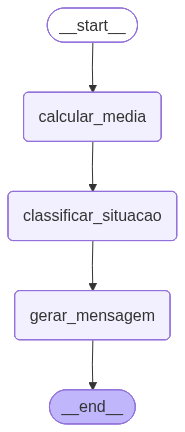

In [25]:
class EstadoComHistorico(TypedDict):
    nome: str
    notas: list[float]
    media: float
    situacao: str
    mensagem: str

    # Este campo será acumulado com operator.add.
    historico: Annotated[list[str], add]


def calcular_media_com_historico(state: EstadoComHistorico) -> dict:
    media = sum(state["notas"]) / len(state["notas"])

    return {
        "media": media,
        "historico": [f"Média calculada: {media:.2f}"]
    }


def classificar_situacao(state: EstadoComHistorico) -> dict:
    media = state["media"]

    if media >= 7:
        situacao = "aprovado"
    else:
        situacao = "em recuperação"

    return {
        "situacao": situacao,
        "historico": [f"Situação classificada como: {situacao}"]
    }


def gerar_mensagem_com_historico(state: EstadoComHistorico) -> dict:
    mensagem = (
        f"Olá, {state['nome']}! "
        f"Sua média foi {state['media']:.2f} e sua situação é: {state['situacao']}."
    )

    return {
        "mensagem": mensagem,
        "historico": ["Mensagem final gerada"]
    }


builder = StateGraph(EstadoComHistorico)

builder.add_node("calcular_media", calcular_media_com_historico)
builder.add_node("classificar_situacao", classificar_situacao)
builder.add_node("gerar_mensagem", gerar_mensagem_com_historico)

builder.add_edge(START, "calcular_media")
builder.add_edge("calcular_media", "classificar_situacao")
builder.add_edge("classificar_situacao", "gerar_mensagem")
builder.add_edge("gerar_mensagem", END)

graph = builder.compile()

resultado = graph.invoke({
    "nome": "Julio",
    "notas": [6.5, 7.0, 8.0],
    "historico": []
})

historico = resultado['historico']
print(f'Histórico: {historico}')

display(Image(graph.get_graph().draw_mermaid_png()))

## 6.2 Por que reducers são importantes?

Reducers são importantes quando o estado tem campos acumulativos, como:

- histórico de mensagens;
- logs de execução;
- documentos recuperados;
- passos intermediários;
- resultados vindos de múltiplos nós;
- mensagens de uma conversa.

Sem reducer, a atualização mais recente pode sobrescrever o valor anterior.

Com reducer, conseguimos definir uma regra clara de combinação.


---

# 7. Ciclos: gerar, avaliar e tentar novamente

Grafos podem ter ciclos.  
Isso significa que o fluxo pode voltar para uma etapa anterior.

Esse é um dos recursos que diferencia LangGraph de uma sequência linear simples.

Vamos criar um exemplo didático:

1. Gerar uma recomendação de estudo.
2. Avaliar se ela é específica o suficiente.
3. Se estiver ruim, gerar novamente.
4. Finalizar quando estiver boa ou quando atingir o limite de tentativas.

Fluxo:

```text
START
  ↓
gerar_recomendacao
  ↓
avaliar_recomendacao
  ├── repetir → gerar_recomendacao
  └── finalizar → END
```


{'nome': 'Julio', 'disciplina': 'matemática', 'media': 6.2, 'tentativas': 2, 'recomendacao': 'Revise os tópicos principais de matemática, resolva exercícios práticos e separe 30 minutos por dia para corrigir os erros das questões anteriores.', 'avaliacao': 'boa', 'historico': ['Tentativa 1: recomendação gerada', 'Avaliação da recomendação: precisa_melhorar', 'Tentativa 2: recomendação gerada', 'Avaliação da recomendação: boa']}


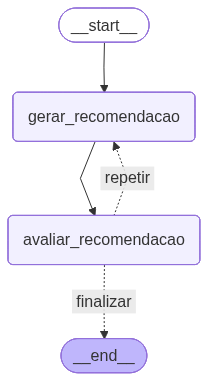

In [28]:
class EstadoRecomendacao(TypedDict):
    nome: str
    disciplina: str
    media: float

    tentativas: int
    recomendacao: str
    avaliacao: str

    historico: Annotated[list[str], add]


def gerar_recomendacao(state: EstadoRecomendacao) -> dict:
    tentativa = state.get("tentativas", 0) + 1

    if tentativa == 1:
        recomendacao = "Estude mais."
    else:
        recomendacao = (
            f"Revise os tópicos principais de {state['disciplina']}, "
            "resolva exercícios práticos e separe 30 minutos por dia "
            "para corrigir os erros das questões anteriores."
        )

    return {
        "tentativas": tentativa,
        "recomendacao": recomendacao,
        "historico": [f"Tentativa {tentativa}: recomendação gerada"]
    }


def avaliar_recomendacao(state: EstadoRecomendacao) -> dict:
    recomendacao = state["recomendacao"]

    tem_exercicios = "exercícios" in recomendacao.lower()
    tem_tempo = "minutos" in recomendacao.lower() or "horas" in recomendacao.lower()
    eh_especifica = len(recomendacao.split()) >= 15

    if tem_exercicios and tem_tempo and eh_especifica:
        avaliacao = "boa"
    else:
        avaliacao = "precisa_melhorar"

    return {
        "avaliacao": avaliacao,
        "historico": [f"Avaliação da recomendação: {avaliacao}"]
    }


def decidir_proximo_passo(
    state: EstadoRecomendacao
) -> Literal["repetir", "finalizar"]:
    if state["avaliacao"] == "boa":
        return "finalizar"

    if state["tentativas"] >= 3:
        return "finalizar"

    return "repetir"


builder = StateGraph(EstadoRecomendacao)

builder.add_node("gerar_recomendacao", gerar_recomendacao)
builder.add_node("avaliar_recomendacao", avaliar_recomendacao)

builder.add_edge(START, "gerar_recomendacao")
builder.add_edge("gerar_recomendacao", "avaliar_recomendacao")

builder.add_conditional_edges(
    "avaliar_recomendacao",
    decidir_proximo_passo,
    {
        "repetir": "gerar_recomendacao",
        "finalizar": END,
    }
)

graph = builder.compile()

resultado = graph.invoke({
    "nome": "Julio",
    "disciplina": "matemática",
    "media": 6.2,
    "tentativas": 0,
    "historico": []
})

print(resultado)
display_graph(graph)

## 7.1 Vendo o ciclo acontecer

Com `stream`, conseguimos visualizar a primeira tentativa, a avaliação e a repetição.


In [29]:
entrada = {
    "nome": "Julio",
    "disciplina": "matemática",
    "media": 6.2,
    "tentativas": 0,
    "historico": []
}

for evento in graph.stream(entrada, stream_mode="updates"):
    print(evento)


{'gerar_recomendacao': {'tentativas': 1, 'recomendacao': 'Estude mais.', 'historico': ['Tentativa 1: recomendação gerada']}}
{'avaliar_recomendacao': {'avaliacao': 'precisa_melhorar', 'historico': ['Avaliação da recomendação: precisa_melhorar']}}
{'gerar_recomendacao': {'tentativas': 2, 'recomendacao': 'Revise os tópicos principais de matemática, resolva exercícios práticos e separe 30 minutos por dia para corrigir os erros das questões anteriores.', 'historico': ['Tentativa 2: recomendação gerada']}}
{'avaliar_recomendacao': {'avaliacao': 'boa', 'historico': ['Avaliação da recomendação: boa']}}


## 7.2 Critério de parada

Todo ciclo precisa de um critério de parada.

Neste exemplo, o fluxo termina quando:

- a recomendação é avaliada como boa; ou
- o número de tentativas chega a 3.

Sem critério de parada, o grafo poderia repetir indefinidamente.

Esse é um conceito essencial antes de construir agentes mais sofisticados.


---

# 8. Exercícios de fixação

## Exercício 1 — Modificar o primeiro grafo

No exemplo de boas-vindas, adicione um campo `curso` ao estado.

A mensagem final deve ficar parecida com:

```text
Olá, Julio! Você está aprendendo LangGraph no curso de Agentes com IA.
```

---

## Exercício 2 — Melhorar o cálculo de média

No exemplo de média do aluno, adicione um campo `situacao`.

Regras:

- média maior ou igual a 7: `aprovado`;
- média entre 5 e 6.99: `recuperação`;
- média menor que 5: `reprovado`.

---

## Exercício 3 — Nova rota condicional

No grafo de operações, adicione uma nova operação:

```text
"menor_nota"
```

Ela deve retornar a menor nota da lista.

---

## Exercício 4 — Histórico com reducer

No grafo de notas, adicione um campo `historico` e faça cada nó registrar o que fez.

Exemplo esperado:

```python
[
    "Médias por etapa calculadas",
    "Média final calculada",
    "Relatório gerado"
]
```
---

## Exercício 5 — Ciclo com limite diferente

No exemplo de recomendação, altere o limite máximo de tentativas de 3 para 5.

Depois, modifique a função de avaliação para exigir que a recomendação tenha pelo menos 25 palavras.


---

# 9. Resumo da aula

Nesta aula, vimos os fundamentos práticos de LangGraph a partir de exemplos pequenos, executáveis e sem uso de LLMs.

O objetivo foi entender o modelo mental do LangGraph: em vez de pensar apenas em uma sequência linear de execução, passamos a representar a aplicação como um grafo composto por estado, nós, arestas, decisões e ciclos.

| Conceito | Ideia principal |
|---|---|
| Grafo | Estrutura que organiza o fluxo de execução |
| Estado | Dados compartilhados entre os nós |
| Nó | Função que executa uma etapa do fluxo |
| Atualização parcial | Retorno contendo apenas os campos alterados no estado |
| Aresta | Conexão que define o próximo passo do fluxo |
| Roteamento condicional | Escolha do próximo nó com base no estado |
| Reducer | Regra para acumular ou combinar atualizações no estado |
| Ciclo | Fluxo que pode retornar para uma etapa anterior |
| Critério de parada | Condição que evita repetições infinitas |

A ideia principal da aula é:

> LangGraph permite transformar fluxos de execução em grafos explícitos, onde estado, etapas, decisões e ciclos ficam visíveis e controláveis.

---

## 9.1 Checklist de compreensão

Antes de seguir para grafos com LLMs, você deve conseguir responder:

1. O que é o estado em LangGraph?
2. Qual é a função de um nó?
3. Por que um nó normalmente retorna apenas uma atualização parcial do estado?
4. Qual é a diferença entre uma aresta simples e uma aresta condicional?
5. Quando um reducer é necessário?
6. Por que ciclos precisam de um critério de parada?
7. Como `stream` ajuda a observar a execução do grafo?
8. Como o LangGraph ajuda a organizar fluxos com múltiplas etapas?

---

## 9.2 Próximos passos

Usamos LangGraph sem LLMs para entender os fundamentos do framework.

Veremos como introduzir LLMs dentro do LangGraph e trabalhar com:

- estado baseado em mensagens;
- chatbot mínimo;
- prompt de sistema dentro de nós;
- observação da execução com `stream`;
- LLM como classificador de intenção;
- roteamento condicional com base na saída do modelo;
- ciclos simples de geração, avaliação e revisão.

A transição natural é sair de grafos com funções Python simples para grafos que orquestram chamadas de modelos de linguagem.

---

# 10. Referências

- Documentação oficial do LangGraph: https://docs.langchain.com/oss/python/langgraph/overview
- LangGraph — Graph API: https://docs.langchain.com/oss/python/langgraph/graph-api
- Repositório oficial do LangGraph: https://github.com/langchain-ai/langgraph